In [1]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3, MobileNetV2
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os
import numpy as np
from google.colab import drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_dir = '/content/drive/MyDrive/skin_disease/train'
test_dir = '/content/drive/MyDrive/skin_disease/test'

# Image preprocessing and augmentation
image_size = (224, 224)
batch_size = 32

# Training data with 80% for training and 20% for validation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Reserve 20% of training data for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Training set (80%)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use the training subset
)

# Validation set (20%)
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use the validation subset
)

# Test set
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)




Found 741 images belonging to 8 classes.
Found 183 images belonging to 8 classes.
Found 233 images belonging to 8 classes.


In [ ]:
# Get the number of classes dynamically from the data generator
num_classes = train_generator.num_classes
print(f"Number of classes: {num_classes}")

# Load InceptionV3 and MobileNetV2 with pre-trained ImageNet weights
inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze their weights so we don't train them initially
inception_base.trainable = False
mobilenet_base.trainable = False

# Input layer
input_tensor = Input(shape=(224, 224, 3))

# Feature extraction layers
inception_features = inception_base(input_tensor)
mobilenet_features = mobilenet_base(input_tensor)

# Global average pooling for both models
inception_pooling = GlobalAveragePooling2D()(inception_features)
mobilenet_pooling = GlobalAveragePooling2D()(mobilenet_features)

# Combine the outputs of both models
combined = Concatenate()([inception_pooling, mobilenet_pooling])

# Add some dense layers on top
x = Dense(512, activation='relu')(combined)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

# Output layer (use num_classes dynamically from the dataset)
output = Dense(num_classes, activation='softmax')(x)

# Build the final model
model = Model(inputs=input_tensor, outputs=output)

# Print model summary
model.summary()



Number of classes: 8
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_v3        │ (None, 5, 5,      │ 21,802,784 │ input_layer_2[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ inception_v3[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,704,448 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │      2,056 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,898,600 (98.80 MB)

 Trainable params: 1,837,832 (7.01 MB)

 Non-trainable params: 24,060,768 (91.78 MB)

In [ ]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
epochs = 10  # You can increase this for better performance
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 313s 12s/step - accuracy: 0.2012 - loss: 2.3233 - val_accuracy: 0.6393 - val_loss: 1.4426
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 201s 7s/step - accuracy: 0.3779 - loss: 1.6507 - val_accuracy: 0.7432 - val_loss: 1.0336
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 172s 7s/step - accuracy: 0.6201 - loss: 1.1478 - val_accuracy: 0.8470 - val_loss: 0.7813
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 173s 7s/step - accuracy: 0.6995 - loss: 0.9130 - val_accuracy: 0.8415 - val_loss: 0.6129
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 180s 8s/step - accuracy: 0.7286 - loss: 0.8286 - val_accuracy: 0.8634 - val_loss: 0.5134
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 194s 7s/step - accuracy: 0.7915 - loss: 0.6365 - val_accuracy: 0.8852 - val_loss: 0.4459
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 178s 7s/step - accuracy: 0.8101 - loss: 0.5594 - val_accuracy: 0.8962 - val_loss: 0.4090
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 183s 8s/step - accuracy: 0.8736 - loss: 0.4439 - val_accuracy: 0.9126 - 

In [ ]:
# Unfreeze the layers of both models
inception_base.trainable = True
mobilenet_base.trainable = True

# Recompile the model with a lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Continue training (fine-tuning)
fine_tune_epochs = 10  # Adjust as needed
history_fine_tune = model.fit(
    train_generator,
    epochs=fine_tune_epochs,
    validation_data=val_generator
)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 702s 25s/step - accuracy: 0.4757 - loss: 1.5096 - val_accuracy: 0.9071 - val_loss: 0.3410
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 578s 24s/step - accuracy: 0.6135 - loss: 1.1507 - val_accuracy: 0.8525 - val_loss: 0.3949
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 629s 24s/step - accuracy: 0.6989 - loss: 1.0132 - val_accuracy: 0.9071 - val_loss: 0.3430
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 586s 24s/step - accuracy: 0.7004 - loss: 0.8763 - val_accuracy: 0.8907 - val_loss: 0.3772
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 595s 25s/step - accuracy: 0.7699 - loss: 0.7086 - val_accuracy: 0.9016 - val_loss: 0.3324
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 573s 24s/step - accuracy: 0.7940 - loss: 0.6593 - val_accuracy: 0.9180 - val_loss: 0.3122
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 581s 24s/step - accuracy: 0.8439 - loss: 0.5780 - val_accuracy: 0.8962 - val_loss: 0.3284
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 583s 24s/step - accuracy: 0.8123 - loss: 0.5671 - val_accuracy: 0.

In [ ]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test accuracy: {test_accuracy * 100:.2f}%')


8/8 ━━━━━━━━━━━━━━━━━━━━ 61s 7s/step - accuracy: 0.9085 - loss: 0.2510
Test accuracy: 90.13%


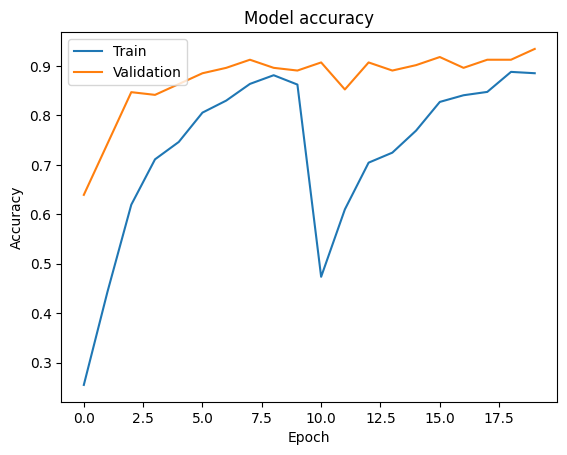

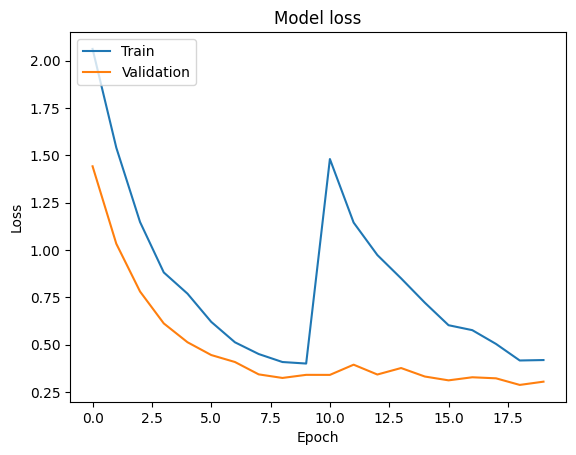

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'] + history_fine_tune.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_fine_tune.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'] + history_fine_tune.history['loss'])
plt.plot(history.history['val_loss'] + history_fine_tune.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


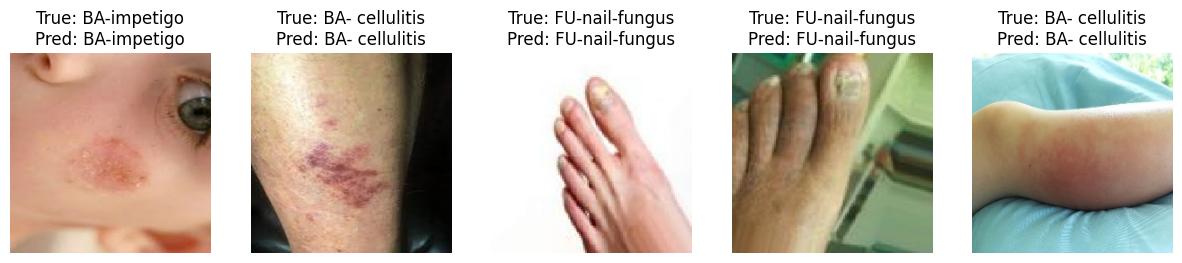

In [ ]:
# Get a batch of test images and labels
test_images, test_labels = next(test_generator)

# Get the class labels from the generator
class_labels = list(test_generator.class_indices.keys())

# Predict the probabilities for the batch of test images
predictions = model.predict(test_images)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)

# Display a few test images with predicted and true labels
def display_sample_predictions(test_images, true_classes, predicted_classes, class_labels, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(test_images[i])
        true_label = class_labels[true_classes[i]]
        predicted_label = class_labels[predicted_classes[i]]
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis('off')
    plt.show()

# Display the first 5 images with predictions
display_sample_predictions(test_images, true_classes, predicted_classes, class_labels)

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Get the class names from the train_generator (you can also use test_generator)
class_labels = list(train_generator.class_indices.keys())  # This gives you the disease names in the order of their indices

# Function to predict the class of the uploaded image
def predict_image(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))  # Ensure size matches model input
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Convert to batch format
    img_array /= 255.0  # Rescale as done during training

    # Make the prediction
    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction, axis=1)[0]  # Get the index of the highest prediction score
    predicted_class_name = class_labels[predicted_class_index]  # Get the class name using the index

    # Display the image with predicted label
    plt.imshow(img)
    plt.title(f'Predicted Class: {predicted_class_name}')
    plt.axis('off')
    plt.show()

    return predicted_class_name

# Allow the user to upload an image file
uploaded = files.upload()

# Get the file name (only one file will be uploaded)
for file_name in uploaded.keys():
    predicted_class_name = predict_image(file_name)  # Use the uploaded file
    print(f'Predicted class: {predicted_class_name}')



KeyboardInterrupt: 

In [ ]:
model.save('skin_disease_model.keras')



In [ ]:
model.save('/content/drive/MyDrive/skin_disease_model.keras')
